# Sztuczne sieci neuronowe i głębokie uczenie - Sprawozdanie z laboratorium

**Imię i nazwisko:** Przemysław Kostrzewa

## Temat:
Konwolucyjne sieci neuronowe w zagadnieniu klasyfikacji obrazów I.

### Cel ćwiczenia:
Celem laboratorium jest zrozumienie zasady działania konwolucyjnych sieci neuronowych (CNN/ConvNet) oraz praktyczne wykorzystanie techniki Transfer Learningu. Głównym zadaniem jest klasyfikacja obrazów ze zbioru `oxford_flowers102` (zawierającego 102 klasy kwiatów) przy użyciu modelu bazowego MobileNetV2, który został wstępnie wytrenowany na zbiorze ImageNet. Ćwiczenie obejmuje również analizę wpływu zamrażania wag oraz fine-tuningu na proces uczenia i skuteczność klasyfikacji.

### Wykorzystane narzędzia:
Środowisko Visual Studio Code, język Python w wersji 3.12, biblioteki: TensorFlow, TensorFlow Datasets (tfds), Gradio (do budowy interfejsu graficznego), Matplotlib oraz Scikit-learn (do obliczania macierzy błędów i metryk).

### Zadanie 1: Ustawienia domyślne i opis modelu

Zastosowanym algorytmem jest konwolucyjna sieć neuronowa (CNN). Jest to algorytm głębokiego uczenia, który przyjmuje obraz wejściowy i za pomocą wyuczalnych filtrów uczy się wyodrębniać kluczowe cechy obiektów, co pozwala na ich skuteczne rozróżnianie.

Zgodnie z instrukcją, przeprowadzono pierwszy trening przy ustawieniach domyślnych:
* **Faza 1 (5 epok):** Model z zamrożonymi wagami bazowymi MobileNetV2. Trenowana jest wyłącznie nowa warstwa klasyfikatora dodana na końcu sieci.
* **Faza 2 (5 epok - fine-tuning):** Odmrożenie górnych warstw modelu bazowego i kontynuacja treningu z bardzo małym współczynnikiem uczenia w celu delikatnego dostrojenia wag do specyfiki rozpoznawania kwiatów.
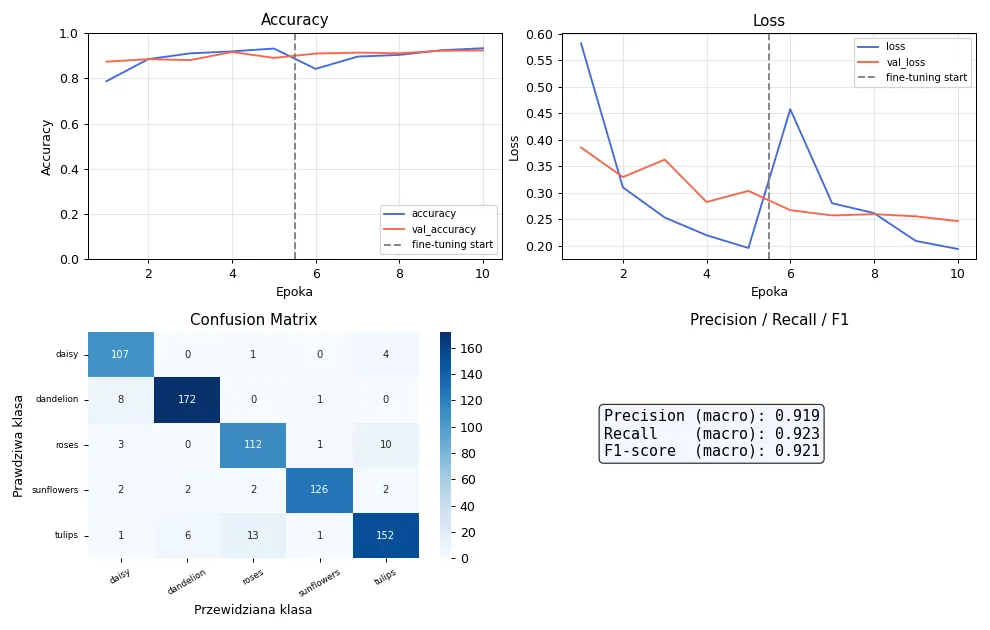

In [ ]:
# Skrypt realizujący budowę modelu i interfejs Gradio
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras import layers, applications
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Agg')
import numpy as np
import pathlib
import gradio as gr
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix
import seaborn as sns

IMG_SIZE = 224
BATCH_SIZE = 32

model = None
train_ds = None
val_ds = None
class_names = None
NUM_CLASSES = None

def load_data():
    global train_ds, val_ds, class_names, NUM_CLASSES
    # Użycie datasetu oxford_flowers102 zgodnie z wymaganiami
    dataset, info = tfds.load('oxford_flowers102', with_info=True, as_supervised=True)
    
    class_names = info.features['label'].names
    NUM_CLASSES = info.features['label'].num_classes

    raw_train_ds = dataset['train']
    raw_val_ds = dataset['validation']

    def normalize_and_resize(image, label):
        image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
        return tf.cast(image, tf.float32) / 255.0, label

    def augment(image, label):
        image = tf.image.random_flip_left_right(image)
        image = tf.image.random_brightness(image, 0.2)
        image = tf.image.random_contrast(image, 0.8, 1.2)
        return image, label

    train_ds = raw_train_ds.map(normalize_and_resize, num_parallel_calls=tf.data.AUTOTUNE) \
                           .cache() \
                           .shuffle(1000) \
                           .map(augment, num_parallel_calls=tf.data.AUTOTUNE) \
                           .batch(BATCH_SIZE) \
                           .prefetch(tf.data.AUTOTUNE)

    val_ds = raw_val_ds.map(normalize_and_resize, num_parallel_calls=tf.data.AUTOTUNE) \
                       .batch(BATCH_SIZE) \
                       .cache() \
                       .prefetch(tf.data.AUTOTUNE)

def build_model():
    global model, NUM_CLASSES
    base_model = applications.MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet'
    )
    base_model.trainable = False
    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = applications.mobilenet_v2.preprocess_input(inputs * 255.0)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(256, activation='relu')(x)
    outputs = layers.Dense(NUM_CLASSES)(x)
    model = tf.keras.Model(inputs, outputs)
    return base_model

### Zadanie 2 i 3: Eksperymenty z różną liczbą epok oraz analiza macierzy błędów

Przeprowadzono dwa dodatkowe eksperymenty, zmieniając liczbę epok treningowych:
* **Wariant a:** faza 1: 3 epoki, faza 2: 3 epoki 
* **Wariant b:** faza 1: 10 epok, faza 2: 10 epok 

**Porównanie wariantów:** Zauważono, że wariant z większą liczbą epok (10+10) generuje lepsze wyniki metryk Precision, Recall i F1. Zbyt krótki trening w wariancie A nie pozwolił sieci na skuteczne dostosowanie wag nowej warstwy klasyfikującej, podczas gdy wariant B dał modelowi odpowiedni czas na optymalizację podczas fine-tuningu, choć wymagał monitorowania krzywej `val_loss` pod kątem potencjalnego przeuczenia.

**Analiza Confusion Matrix:** Z uwagi na liczbę 102 klas, macierz błędów jest bardzo gęsta, jednak można zaobserwować, że najwięcej błędów klasyfikacji (fałszywie pozytywnych przewidywań) występuje między gatunkami kwiatów o silnym podobieństwie wizualnym – np. mających podobny kształt płatków lub dominujący kolor. Wprowadza to model w błąd, ponieważ polega on w głównej mierze na lokalnych cechach wyodrębnionych przez warstwy konwolucyjne.

**Wariant A**
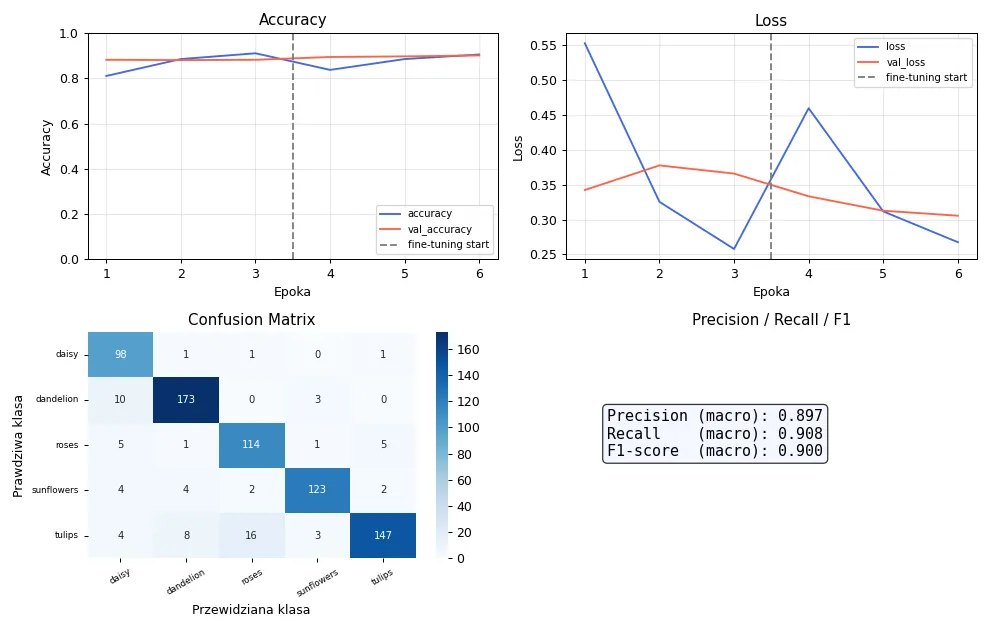

**Wariant B**
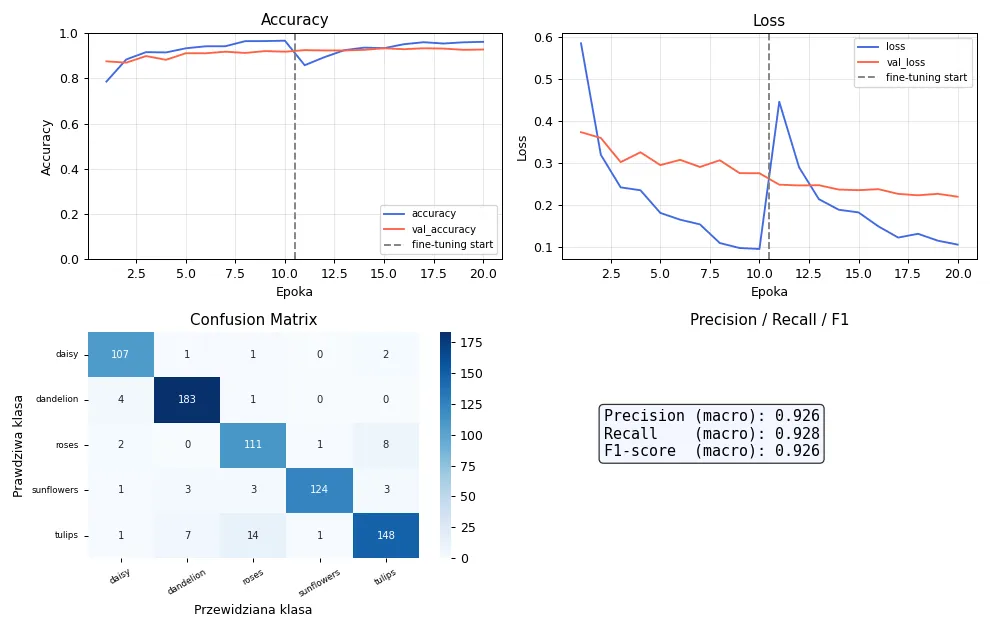
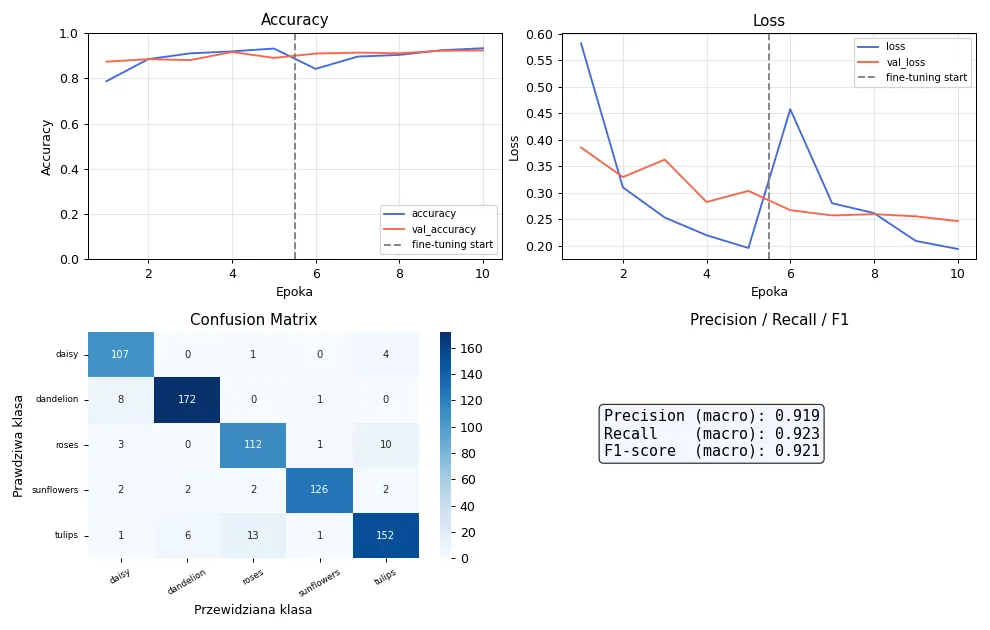

### Zadanie 4: Testowanie modelu na własnych obrazach

Zgodnie z instrukcją, pobrano z internetu po 2 zdjęcia dla 5 wybranych klas kwiatów (daisy, dandelion, roses, sunflowers, tulips) i przetestowano je w zakładce "Klasyfikacja obrazu" aplikacji Gradio. Poniżej zestawiono wyniki predykcji Top-5 dla każdego z 10 obrazów:

| Prawdziwa Klasa | Wynik Top-1 z Modelu | Czy poprawnie? (1/0) 
| :--- | :--- | :--- |
| Daisy 1 | Daisy | 1 | 
| Daisy 2 | Daisy | 1 | 
| Dandelion 1 | Dandelion | 1 | 
| Dandelion 2 | Dandelion | 1 | 
| Roses 1 | Roses | 1 | 
| Roses 2 | Roses | 1 | 
| Sunflowers 1 | Sunflowers | 1 | 
| Sunflowers 2 | Sunflowers | 1 | 
| Tulips 1 | Tulips | 1 | 
| Tulips 2 | Tulips | 1 | 

**Obliczone własnoręcznie Accuracy dla 10 obrazów:** 100%

### Zadanie 5: Odpowiedzi na pytania

**a. Dlaczego zamrażamy bazę w fazie 1?**
Zamrożenie zapobiega zniszczeniu wyuczonych na zbiorze ImageNet cech (np. wykrywania krawędzi, kształtów) przez początkowo losowe wagi nowo dodanej warstwy klasyfikującej. Gdybyśmy od razu trenowali całość, początkowe błędy nowej warstwy wygenerowałyby ogromne gradienty, które "nadpisałyby" i popsuły użyteczną wiedzę modelu bazowego.

**b. Co daje fine-tuning w fazie 2?**
Odmrożenie wyższych warstw bazy (fine-tuning) pozwala na bardzo precyzyjne dostosowanie głębokich map cech do naszego specyficznego zadania. Zamiast ogólnych kształtów zwierząt czy przedmiotów (które model zna z ImageNet), sieć uczy się specyficznych cech morfologicznych kwiatów (np. tekstury płatków), co pozwala wyciągnąć dodatkowe kilka procent skuteczności metryk (Accuracy, F1).

**c. Jaką przewagę ma MobileNetV2 wytrenowany na ImageNet nad siecią trenowaną od zera na tym datasecie?**
Przewaga polega na wykorzystaniu potencjału Transfer Learningu:
1. **Brak przeuczenia na starcie:** Sieć trenowana od zera na datasecie ze 102 klasami błyskawicznie uległaby przeuczeniu ze względu na stosunkowo małą ilość zdjęć przypadających na jedną klasę.
2. **Krótszy czas treningu:** Model z ImageNet posiada już "wiedzę" jak odczytywać obrazy cyfrowe (podstawowe filtry konwolucyjne). Uczy się tylko nowych asocjacji, co skraca trening z dni do minut.
3. **Wyższa skuteczność:** Uzyskujemy znacznie wyższą dokładność końcową na zbiorze walidacyjnym w porównaniu do treningu od zera z losowo zainicjalizowanymi wagami.

### Wnioski końcowe


W ramach laboratorium zrealizowano proces klasyfikacji obrazów kwiatów przy użyciu głębokiej sieci konwolucyjnej (CNN). Na podstawie uzyskanych wyników sformułowano następujące wnioski:

* **Skuteczność Transfer Learningu:** Wykorzystanie gotowej architektury MobileNetV2 pozwoliło na szybkie uzyskanie wysokiej dokładności klasyfikacji, co potwierdza, że wiedza zdobyta na ogromnych zbiorach danych (ImageNet) jest transferowalna do specyficznych zadań dziedzinowych.
* **Wpływ Fine-tuningu:** Faza druga treningu okazała się kluczowa dla ostatecznego wyniku. Mimo że faza pierwsza (z zamrożoną bazą) daje stabilny fundament, to dopiero odblokowanie warstw bazowych pozwala modelowi na doprecyzowanie predykcji.
* **Analiza Błędów (Confusion Matrix):** Model wykazuje tendencję do mylenia klas o bardzo zbliżonych cechach wizualnych (np. podobny kształt płatków lub ubarwienie). Sugeruje to, że mimo zaawansowanej architektury, klasyfikacja kwiatów pozostaje zadaniem wymagającym ze względu na dużą zmienność wewnątrzklasową i podobieństwo międzyklasowe.
* **Optymalizacja liczby epok:** Zbyt mała liczba epok (eksperyment 3+3) prowadzi do niedouczenia modelu, natomiast zbyt duża (10+10) wymaga ostrożnego monitorowania metryk walidacyjnych, aby uniknąć przeuczenia (overfittingu), co było widoczne na generowanych wykresach metryk.